# SDSSRM-XCS morphology: X-ray peak coordinates

This section of the project measures the hot intra-cluster medium (ICM) X-eay peak coordinates for the SDSSRM-XCS sample of 150 galaxy clusters - the X-ray peak is one of several proxies for the true central coordinate (which we cannot really measure) of a galaxy cluster, and is considered one of the most reliable.

We are primarily measuring them to support measurements of centroid shift performed in another notebook in this subsection of the project.

## Import Statements

In [1]:
import pandas as pd
pd.set_option('display.max_columns', 500)
import numpy as np
from astropy.units import Quantity, UnitConversionError
from astropy.cosmology import LambdaCDM
from shutil import rmtree
import os
from matplotlib import pyplot as plt

import xga
xga.NUM_CORES = 10
from xga.samples import ClusterSample

# Set up a variable that controls how long individual XSPEC fits are allowed to run
timeout = Quantity(6, 'hr')

%matplotlib inline

## Setting up necessary directories

Here we ensure that the directories we need to store the outputs in have been created:

In [2]:
coords_path = "../../outputs/result_files/positions_and_morphology/"
os.makedirs(coords_path, exist_ok=True)
    
peak_vis_path = "../../outputs/figures/icm_morphology/peak_coord_vis/"
os.makedirs(peak_vis_path, exist_ok=True)

## Loading data files

We load the 'base' SDSSRM-XCS sample file, containing some basic information about galaxy cluster names, positions, and redshifts. This will allow us to setup an XGA cluster sample and measure peak coordinates.

### SDSSRM-XCS base sample

In [3]:
sdssxcs_base = pd.read_csv("../../sample_files/SDSSRM-XCS_base_sample.csv")
sdssxcs_base.head(6)

,name,MEM_MATCH_ID,xapa_ra,xapa_dec,rm_ra,rm_dec,z,r500,r500-,r500+,richness,richness_err,XCS_NAME,R_LAMBDA,xmm_targeted,xmm_serendipitous
0,SDSSXCS-124,124,0.80058,-6.09182,0.798261,-6.091694,0.2475,1181.028,21.202,23.203,109.550,4.490,XMMXCS J000312.1-060530.5,1.018410,True,False
1,SDSSXCS-2789,2789,0.95554,2.06802,0.956981,2.066469,0.1053,1007.861,17.194,17.202,38.904,2.830,XMMXCS J000349.3+020404.8,0.827942,True,False
2,SDSSXCS-290,290,2.72264,29.16102,2.714137,29.161154,0.3485,913.052,30.879,31.210,105.096,5.994,XMMXCS J001053.4+290939.6,1.009990,True,False
3,SDSSXCS-1018,1018,4.40633,-0.87619,4.406711,-0.878340,0.2144,902.259,22.445,23.366,56.997,3.219,XMMXCS J001737.5-005234.2,0.893655,False,True
4,SDSSXCS-134,134,4.90839,3.60982,4.911069,3.599257,0.2773,1123.321,19.219,19.226,108.604,4.792,XMMXCS J001938.0+033635.3,1.016645,True,False
5,SDSSXCS-119,119,8.46470,-7.86290,8.471426,-7.869543,0.3042,944.275,46.422,46.747,128.192,5.697,XMMXCS J003351.5-075146.4,1.050926,True,False


### Combining tables

We only require the base sample file for this analysis, so we do not need to combine any tables:

In [4]:
sdssxcs_samp = sdssxcs_base

## Defining an XGA ClusterSample

We are going to use the [XGA hierarchical clustering peak finder](https://xga.readthedocs.io/en/latest/notebooks/techniques/hierarchical_clustering_peak_finding.html), which is built into [the RateMap](https://xga.readthedocs.io/en/latest/xga.products.html#xga.products.phot.RateMap.clustering_peak) class - this is the XGA Python class that provides convenient interfaces with count-rate maps. However, we won't use the count-rate map method directly, instead we'll declare a cluster sample and use the hierarchical peak finder that way - the advantage of this approach is twofold; 

**(1)** declaring the cluster sample will assemble a mask to remove contaminating sources from each cluster's observations, which may improve the performance of the peak finder; and **(2)** the GalaxyCluster call to the peak finder is iterative, and will try to converge on the best value.

As we define the ClusterSample with `use_peak=True` and `peak_find_method='hierarchical'`, the peaks will automatically be calculated during declaration. We have also set `clean_obs=False`, which means that **no** checks will be performed on obserations to make sure that a minimum fraction of $R_{500}$ falls on them - this shouldn't be necessary for this analysis.

In [5]:
srcs = ClusterSample(sdssxcs_samp['xapa_ra'].values, sdssxcs_samp['xapa_dec'].values, 
                     sdssxcs_samp['z'].values, sdssxcs_samp['name'].values, 
                     r500=Quantity(sdssxcs_samp['r500'].values, 'kpc'), use_peak=True, 
                     peak_find_method='hierarchical', clean_obs=False)
srcs.info()

Declaring BaseSource Sample:   0%|                                                    | 0/150 [00:00<?, ?it/s]

Declaring BaseSource Sample:   1%|▎                                           | 1/150 [00:08<19:59,  8.05s/it]

Declaring BaseSource Sample:   1%|▌                                           | 2/150 [00:16<19:58,  8.10s/it]

Declaring BaseSource Sample:   2%|▉                                           | 3/150 [00:20<15:28,  6.31s/it]

Declaring BaseSource Sample:   3%|█▏                                          | 4/150 [00:29<18:11,  7.47s/it]

...

Setting up Galaxy Clusters:  99%|██████████████████████████████████████████▋| 149/150 [22:21<00:06,  6.42s/it]

Setting up Galaxy Clusters: 100%|███████████████████████████████████████████| 150/150 [22:27<00:00,  6.10s/it]

Setting up Galaxy Clusters: 100%|███████████████████████████████████████████| 150/150 [22:27<00:00,  8.98s/it]


-----------------------------------------------------
Number of Sources - 150
Redshift Information - True
Sources with ≥1 detection - 150 [100%]
-----------------------------------------------------




/tmp/ipykernel_2140787/2403957131.py:1: UserWarning: Peak finding did not converge for the following; SDSSXCS-29799, using user supplied coordinates
  srcs = ClusterSample(sdssxcs_samp['xapa_ra'].values, sdssxcs_samp['xapa_dec'].values,
/its/home/dt237/.conda/envs/xga_env/lib/python3.12/site-packages/xga/samples/extended.py:308: UserWarning: Non-fatal warnings occurred during the declaration of some sources, to access them please use the suppressed_warnings property of this sample.
  self._check_source_warnings()


## Saving the peak coordinates

We make sure to save the peak coordinates to a truncated sample file (just containing cluster name and the measured positions):

In [6]:
out_df_data = np.concatenate([srcs.names[..., None], srcs.peaks.value], axis=1)
out_df = pd.DataFrame(out_df_data, columns=['name', 'peak_ra', 'peak_dec'])
out_df.to_csv(coords_path + "xga_xmm_peak_coords.csv", index=False)
out_df

,name,peak_ra,peak_dec
0,SDSSXCS-124,0.8003420646226551,-6.093068803070506
1,SDSSXCS-2789,0.9585831735385095,2.0647637602723603
2,SDSSXCS-290,2.7242178107675414,29.16043946166683
3,SDSSXCS-1018,4.40815857330996,-0.8812150476321787
4,SDSSXCS-134,4.909123319135432,3.6041107180435663
...,...,...,...
145,SDSSXCS-2092,350.3572759412466,19.751238034533586
146,SDSSXCS-17923,350.4663274776173,19.88786619490937
147,SDSSXCS-68,354.39815403114847,0.265207805284551
148,SDSSXCS-147,355.31731198369494,-9.025929519670337


## Examine the peak coordinates

We can use the view methods of the XGA RateMap class to visualise the start coordinates and peak coordinates, as well as the 'point clusters' that the hierarchical peak finding method identified and used. This gives some visual context to the peak coordinates, and helps us to make sure that they all look sensible - we also save the visualisations to disk:

SDSSXCS-124


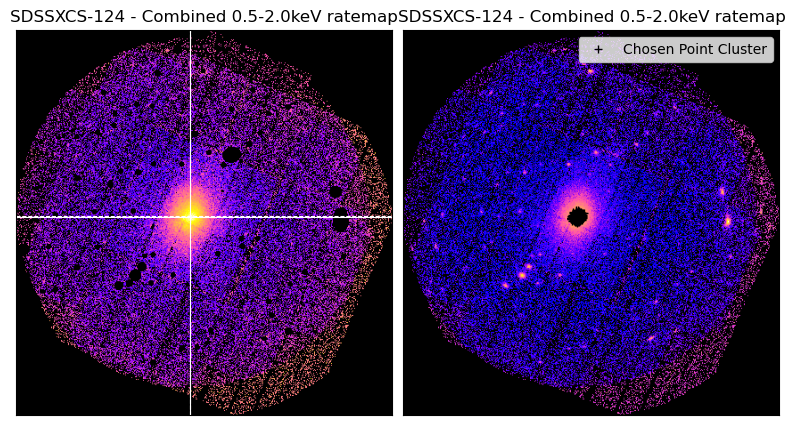

SDSSXCS-2789


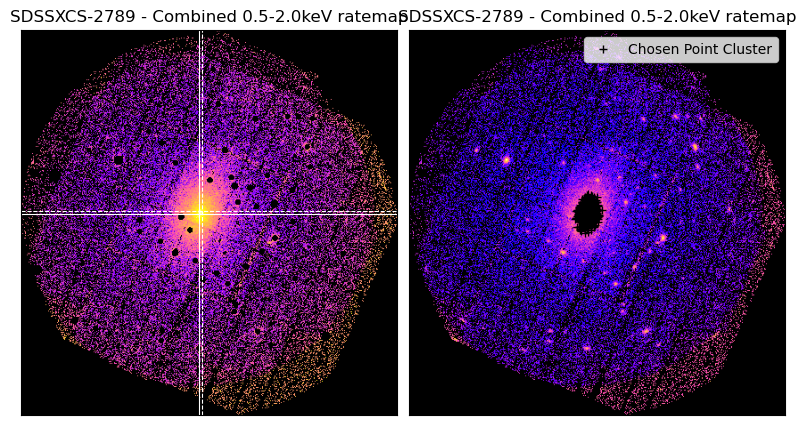

SDSSXCS-290


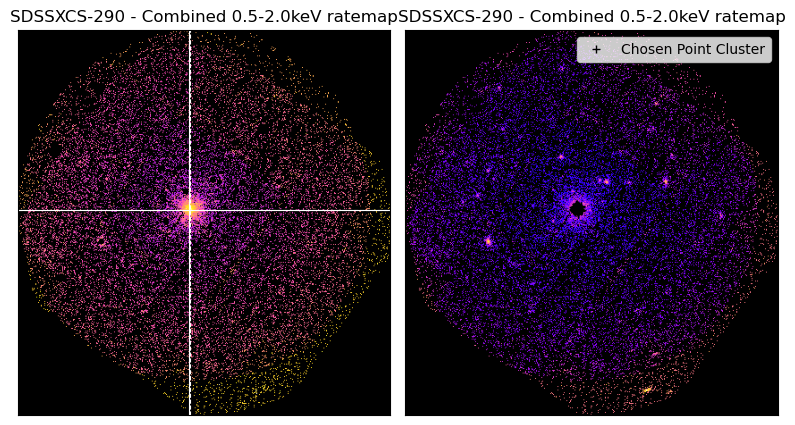

SDSSXCS-1018


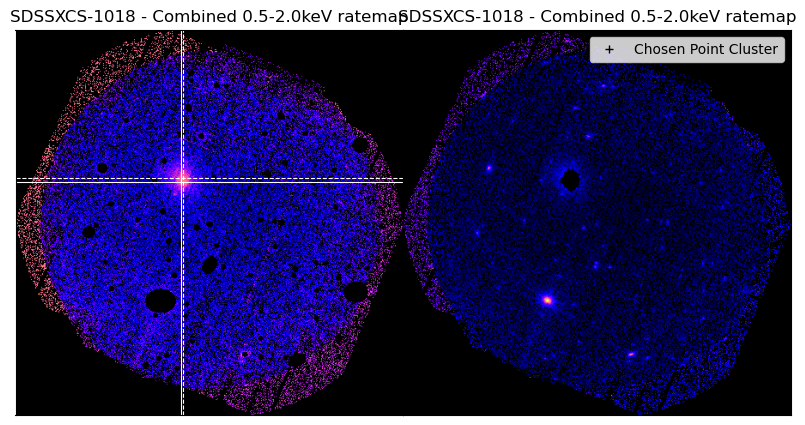

SDSSXCS-134


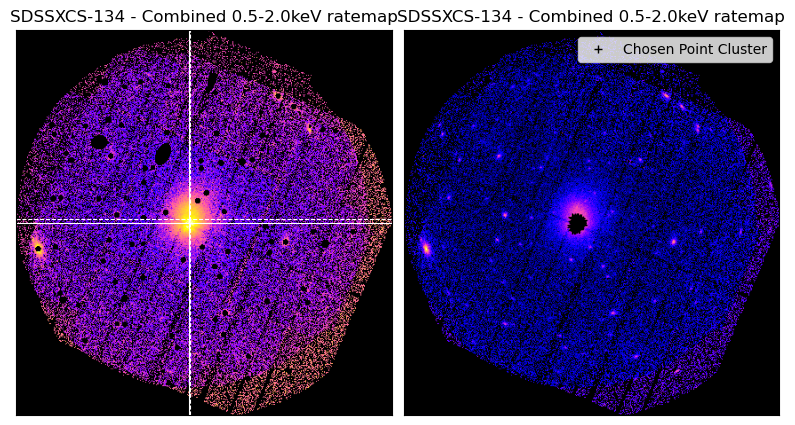

SDSSXCS-119


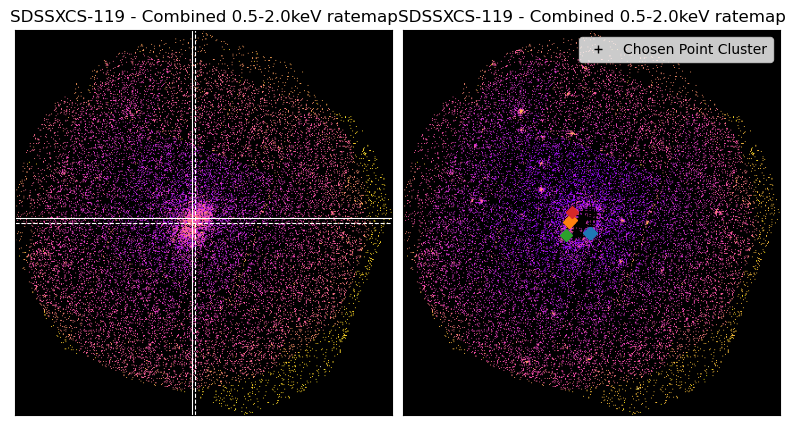

SDSSXCS-209


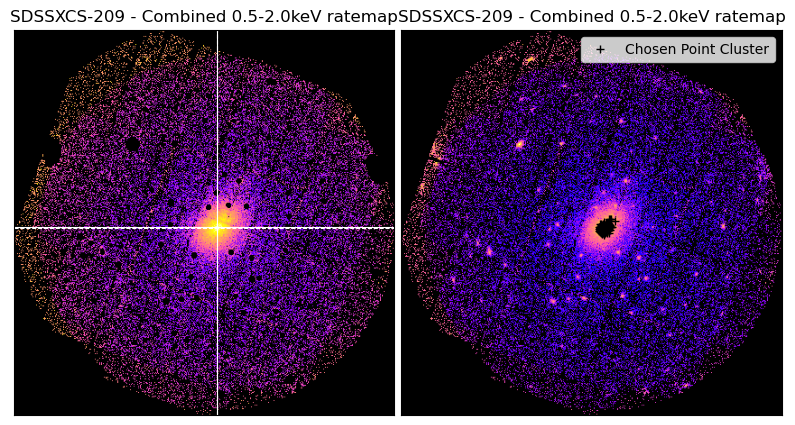

SDSSXCS-15


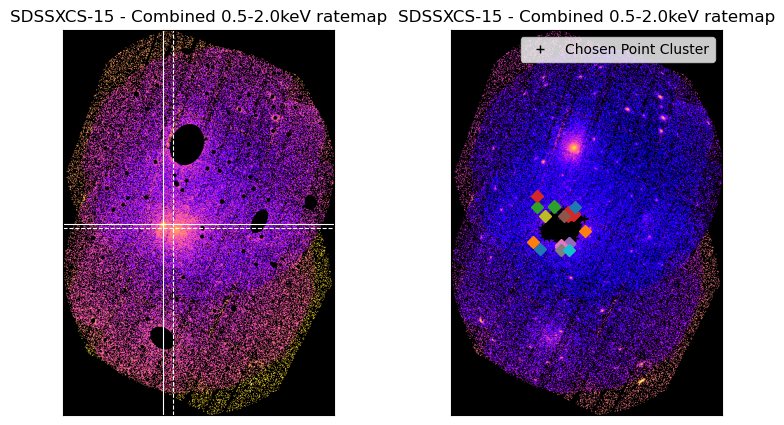

SDSSXCS-71


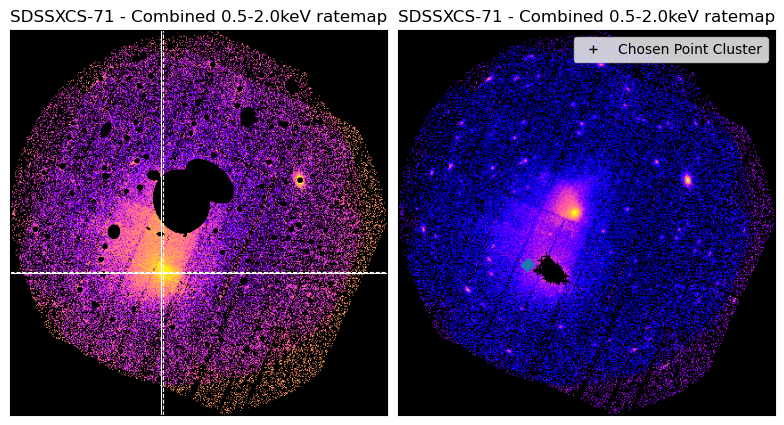

SDSSXCS-5020


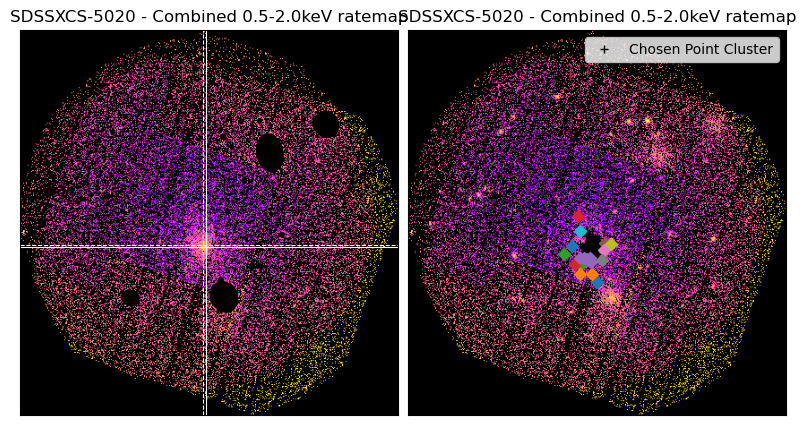

SDSSXCS-29799 - point cluster display issue
25.0

[]



In [7]:
for src_ind, src in enumerate(srcs):
    # Fetch the combined ratemap that was used for peak identification
    cur_rt = src.get_combined_ratemaps()
    cur_chos_pnt_clst = src.point_clusters[0]
    cur_oth_pnt_clst = src.point_clusters[1]
    cur_int_mask = src.get_interloper_mask()

    fig, ax_arr = plt.subplots(ncols=2, figsize=(10, 5), sharey=True)
    fig.subplots_adjust(wspace=0)

    for ax_ind, ax in enumerate(ax_arr):
        plt.tick_params(left=False, right=False, top=False, bottom=False)

    cur_rt.get_view(ax_arr[0], Quantity([src.peak, src.ra_dec]), cur_int_mask, zoom_in=True)

    try:
        cur_rt.get_view(ax_arr[1], chosen_points=cur_chos_pnt_clst, other_points=cur_oth_pnt_clst, zoom_in=True)
    except IndexError:
        print(src.name, '- point cluster display issue')
        print(cur_chos_pnt_clst)
        print('')
        print(cur_oth_pnt_clst)
        print('')
    
    file_name = "{n}_xmm_peak_search_vis.pdf".format(n=src.name)
    plt.savefig(peak_vis_path + file_name, bbox_inches='tight')
    if src_ind < 10:
        print(src.name)
        plt.show()

    plt.close('all')